In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/agneaybnair/custom/data_quality_practice_dataset.xlsx


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_excel("/kaggle/input/datasets/agneaybnair/custom/data_quality_practice_dataset.xlsx")

In [4]:
df.head()

,CustomerID,Age,Income,Gender,City,PurchaseAmount,Churn
0,1,42.0,64606.0,M,Bengaluru,5654,0
1,2,48.0,65781.0,F,Mumbai,1754,0
2,3,60.0,26728.0,F,Bengaluru,3778,0
3,4,49.0,78616.0,F,Bengaluru,5471,0
4,5,34.0,70212.0,F,Bengaluru,5762,0


In [5]:
df.shape

(100, 7)

In [6]:
df.columns

Index(['CustomerID', 'Age', 'Income', 'Gender', 'City', 'PurchaseAmount',
       'Churn'],
      dtype='object')

In [7]:
df.dtypes

CustomerID          int64
Age               float64
Income            float64
Gender             object
City               object
PurchaseAmount      int64
Churn               int64
dtype: object

In [8]:
df.describe()

,CustomerID,Age,Income,PurchaseAmount,Churn
count,100.000000,98.000000,97.000000,100.000000,100.000000
mean,50.500000,41.520408,63079.319588,5634.910000,0.100000
std,29.011492,14.051620,47110.289383,4649.831128,0.301511
min,1.000000,18.000000,23079.000000,1754.000000,0.000000
25%,25.750000,28.500000,47873.000000,4467.250000,0.000000
50%,50.500000,42.000000,60561.000000,5147.500000,0.000000
75%,75.250000,53.000000,70569.000000,5941.250000,0.000000
max,100.000000,65.000000,500000.000000,50000.000000,1.000000


In [9]:
df.isnull().sum()

CustomerID        0
Age               2
Income            3
Gender            0
City              0
PurchaseAmount    0
Churn             0
dtype: int64

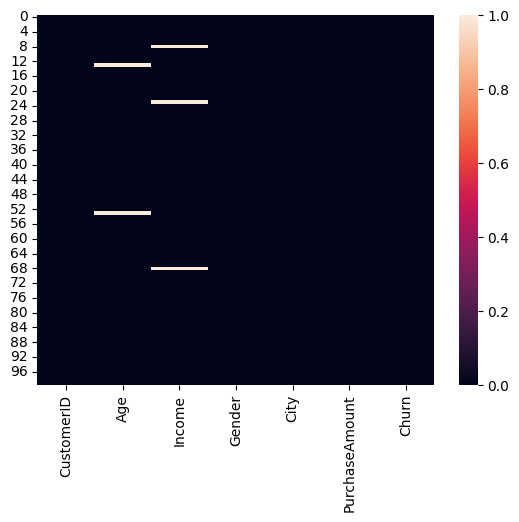

In [10]:
sns.heatmap(df.isnull())
plt.show()

In [11]:
#Mean Imputation
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [12]:
#Mean Imputation
df["Income"] = df["Income"].fillna(df["Income"].mean())

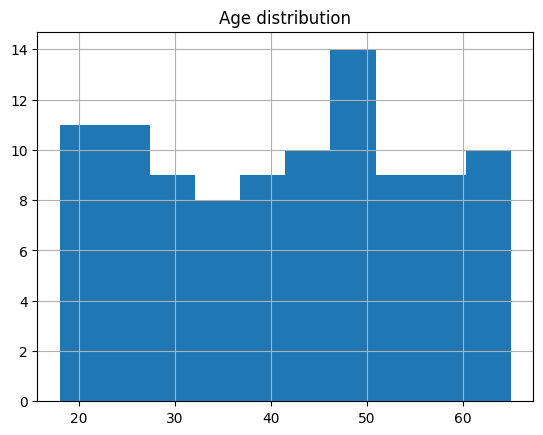

In [13]:
df["Age"].hist(bins=10)
plt.title("Age distribution")
plt.show()

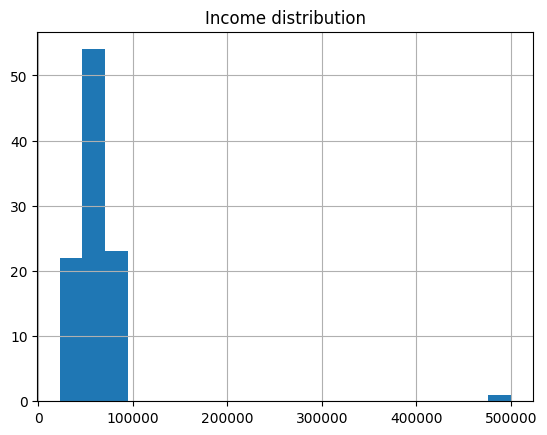

In [14]:
df["Income"].hist(bins=20)
plt.title("Income distribution")
plt.show()

In [15]:
df["Income"].var()


2152125445.606997

In [16]:
df["Income"].std()

46391.00608530706

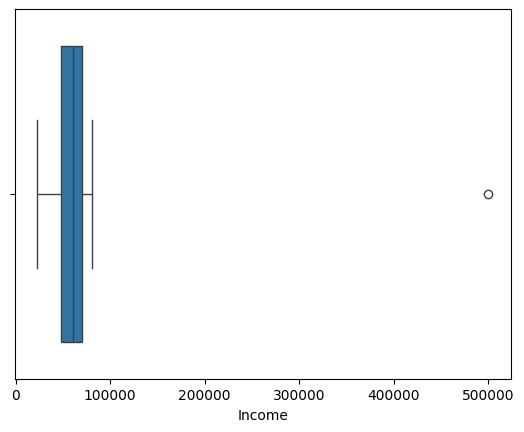

In [17]:
sns.boxplot(x=df["Income"])
plt.show()

In [18]:
# IQR Method
Q1 = df["Income"].quantile(0.25)
Q3 = df["Income"].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
print(lower,upper)

14564.375 103743.375


In [19]:
# Find outliners another method
outliers = df[ (df["Income"] > upper) | (df["Income"] < lower)]

outliers

,CustomerID,Age,Income,Gender,City,PurchaseAmount,Churn
38,39,44.0,500000.0,F,Mumbai,3671,1


In [20]:
df_clean = df[(df["Income"] >= upper) & (df["Income"] < lower)]
df_clean

,CustomerID,Age,Income,Gender,City,PurchaseAmount,Churn


In [21]:
#winzorisation
df["Income"] = np.where(
    df["Income"] > upper,
    upper,
    df["Income"]
)

## Categorical Analysis

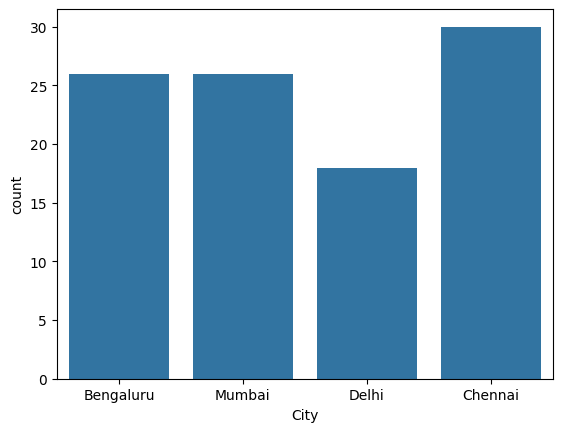

In [22]:
df["Gender"].value_counts()
df["City"].value_counts()

sns.countplot(x="City",data=df)
plt.show(
    
)

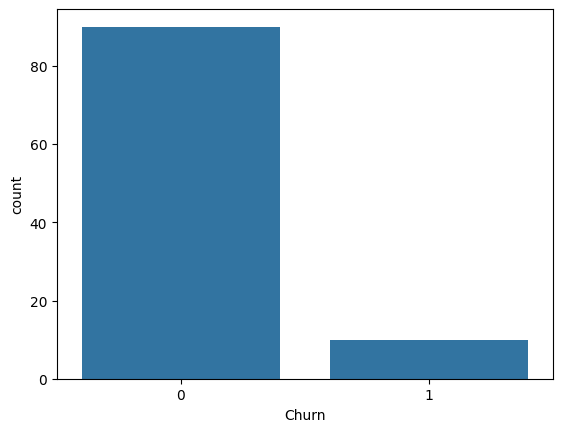

In [23]:
sns.countplot(x="Churn",data=df)
plt.show()

In [24]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()

In [25]:
df.corr(numeric_only=True)

,CustomerID,Age,Income,PurchaseAmount,Churn
CustomerID,1.000000,-0.164679,0.116034,0.104176,0.040417
Age,-0.164679,1.000000,-0.184387,-0.109980,0.103079
Income,0.116034,-0.184387,1.000000,0.063358,0.116749
PurchaseAmount,0.104176,-0.109980,0.063358,1.000000,0.299893
Churn,0.040417,0.103079,0.116749,0.299893,1.000000


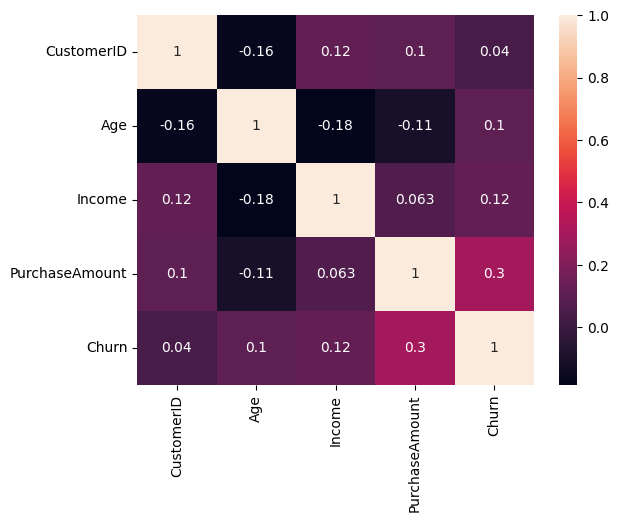

In [26]:
sns.heatmap(
    df.corr(numeric_only=True),
    annot =True
)
plt.show()

In [27]:
pd.get_dummies(df,columns=["Gender","City"])

,CustomerID,Age,Income,PurchaseAmount,Churn,Gender_F,Gender_M,City_Bengaluru,City_Chennai,City_Delhi,City_Mumbai
0,1,42.0,64606.0,5654,0,False,True,True,False,False,False
1,2,48.0,65781.0,1754,0,True,False,False,False,False,True
2,3,60.0,26728.0,3778,0,True,False,True,False,False,False
3,4,49.0,78616.0,5471,0,True,False,True,False,False,False
4,5,34.0,70212.0,5762,0,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
95,96,53.0,40172.0,3698,0,False,True,True,False,False,False
96,97,21.0,35804.0,4574,0,True,False,False,False,True,False
97,98,24.0,71493.0,5392,0,False,True,False,True,False,False
98,99,23.0,73246.0,6291,1,False,True,False,True,False,False


In [28]:
df[["Age","Income"]].head()

,Age,Income
0,42.0,64606.0
1,48.0,65781.0
2,60.0,26728.0
3,49.0,78616.0
4,34.0,70212.0


## Different Scales

In [29]:
#standardisation
scaler = StandardScaler()
df[["Age","Income"]] = scaler.fit_transform(
    df[["Age","Income"]]
)

In [30]:
df.head()

,CustomerID,Age,Income,Gender,City,PurchaseAmount,Churn
0,1,0.034654,0.368049,M,Bengaluru,5654,0
1,2,0.468204,0.446831,F,Mumbai,1754,0
2,3,1.335304,-2.171634,F,Bengaluru,3778,0
3,4,0.540463,1.307406,F,Bengaluru,5471,0
4,5,-0.543412,0.743925,F,Bengaluru,5762,0
